In [ ]:
import os
import math
import random
import numpy as np
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_base = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_base  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

K = 10
class_names = train_base.classes
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
def make_symmetric_C(K, eta):
    C = np.full((K, K), eta / (K - 1), dtype=np.float32)
    np.fill_diagonal(C, 1.0 - eta)
    return C

In [ ]:
def make_asymmetric_cifar10_C(eta):
    C = np.eye(10, dtype=np.float32)
    mapping = {
        9: 1,  # truck -> automobile
        2: 0,  # bird -> airplane
        3: 5,  # cat -> dog
        5: 3,  # dog -> cat
        4: 7,  # deer -> horse
    }
    for src, dst in mapping.items():
        C[src, src] = 1.0 - eta
        C[src, dst] = eta
    return C

In [ ]:
def corrupt_labels(y_true, C, seed=42):
    rng = np.random.default_rng(seed)
    y_noisy = []
    is_noisy = []
    for y in y_true:
        new_y = rng.choice(len(C), p=C[y])
        y_noisy.append(new_y)
        is_noisy.append(int(new_y != y))
    return np.array(y_noisy), np.array(is_noisy)

In [ ]:
class NoisyCIFAR10(Dataset):
    def __init__(self, base_dataset, C, seed=42):
        self.base_dataset = base_dataset
        self.x_data = []
        self.y_true = []
        for x, y in base_dataset:
            self.x_data.append(x)
            self.y_true.append(y)
        self.y_true = np.array(self.y_true)
        self.y_noisy, self.is_noisy = corrupt_labels(self.y_true, C, seed=seed)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x = self.x_data[idx]
        return {
            "x": x,
            "index": idx,
            "y_true": int(self.y_true[idx]),
            "y_noisy": int(self.y_noisy[idx]),
            "is_noisy": int(self.is_noisy[idx]),
        }

In [ ]:
eta = 0.2
C_true = make_symmetric_C(K=10, eta=eta)

train_ds = NoisyCIFAR10(train_base, C_true, seed=42)
test_ds  = NoisyCIFAR10(test_base, C_true, seed=123)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)

In [ ]:
train_noise_rate = np.mean(train_ds.is_noisy)
test_noise_rate = np.mean(test_ds.is_noisy)
print("train noise rate:", train_noise_rate)
print("test noise rate:", test_noise_rate)

train noise rate: 0.19774
test noise rate: 0.2021


In [ ]:
batch = next(iter(train_loader))
print(batch["x"].shape)
print(batch["y_true"][:10])
print(batch["y_noisy"][:10])
print(batch["is_noisy"][:10])

torch.Size([128, 3, 32, 32])
tensor([6, 0, 4, 1, 2, 7, 9, 4, 7, 8])
tensor([6, 0, 4, 3, 2, 7, 0, 6, 7, 8])
tensor([0, 0, 0, 1, 0, 0, 1, 1, 0, 0])


In [ ]:
def one_hot(labels, num_classes):
    return F.one_hot(labels, num_classes=num_classes).float()

In [ ]:
class QyNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        h = self.conv(x)
        logits = self.fc(h)
        return logits

In [ ]:
class QzNet(nn.Module):
    def __init__(self, num_classes=10, z_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4 + num_classes, 256),
            nn.ReLU(),
        )
        self.mu = nn.Linear(256, z_dim)
        self.logvar = nn.Linear(256, z_dim)

    def forward(self, x, y_onehot):
        h = self.conv(x)
        h = torch.cat([h, y_onehot], dim=1)
        h = self.fc(h)
        mu = self.mu(h)
        logvar = self.logvar(h)
        return mu, logvar

In [ ]:
class PxNet(nn.Module):
    def __init__(self, num_classes=10, z_dim=64):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, 128 * 4 * 4),
            nn.ReLU()
        )
        self.deconv = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 32x32
        )

    def forward(self, z, y_onehot):
        h = torch.cat([z, y_onehot], dim=1)
        h = self.fc(h)
        logits = self.deconv(h)
        return logits

In [ ]:
class CorruptionModel(nn.Module):
    def __init__(self, num_classes=10, init_C=None):
        super().__init__()
        if init_C is None:
            init_logits = torch.eye(num_classes)
        else:
            init_logits = torch.log(torch.tensor(init_C) + 1e-6)
        self.logits = nn.Parameter(init_logits)

    def forward(self):
        # row-stochastic: each row is p(y_tilde | y)
        return F.softmax(self.logits, dim=1)

In [ ]:
class DeepGenerativeNoiseModel(nn.Module):
    def __init__(self, num_classes=10, z_dim=64, init_C=None):
        super().__init__()
        self.num_classes = num_classes
        self.z_dim = z_dim
        self.qy = QyNet(num_classes)
        self.qz = QzNet(num_classes, z_dim)
        self.px = PxNet(num_classes, z_dim)
        self.corruption = CorruptionModel(num_classes, init_C=init_C)

    def sample_z(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

In [ ]:
def gaussian_kl(mu, logvar):
    # KL(q(z|x)||N(0,I))
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)

In [ ]:
def bernoulli_log_prob_with_logits(x, logits):
    # return log p(x|z,y)
    # negative BCE summed over pixels
    bce = F.binary_cross_entropy_with_logits(logits, x, reduction="none")
    return -bce.flatten(start_dim=1).sum(dim=1)

In [ ]:
def compute_elbo(model, x, y_tilde):
    """
    x: [B,3,32,32]
    y_tilde: [B]
    returns:
        loss, stats dict
    """
    B = x.size(0)
    K = model.num_classes
    device = x.device

    y_tilde_onehot = one_hot(y_tilde, K).to(device)
    qy_logits = model.qy(x)
    qy_log_probs = F.log_softmax(qy_logits, dim=1)           # [B,K]
    qy_probs = torch.softmax(qy_logits, dim=1)               # [B,K]

    C = model.corruption()                                   # [K,K]
    log_C = torch.log(C + 1e-8)

    log_p_y = math.log(1.0 / K)

    expected_recon = torch.zeros(B, device=device)
    expected_kl_z = torch.zeros(B, device=device)
    expected_log_p_ytilde_given_y = torch.zeros(B, device=device)

    for k in range(K):
        yk = torch.full((B,), k, dtype=torch.long, device=device)
        yk_onehot = one_hot(yk, K).to(device)

        mu_k, logvar_k = model.qz(x, yk_onehot)
        z_k = model.sample_z(mu_k, logvar_k)
        x_logits_k = model.px(z_k, yk_onehot)

        log_p_x_given_z_y = bernoulli_log_prob_with_logits(x, x_logits_k)   # [B]
        kl_z_k = gaussian_kl(mu_k, logvar_k)                                # [B]

        log_p_ytilde_given_yk = log_C[k, y_tilde]                           # [B]

        qk = qy_probs[:, k]                                                 # [B]

        expected_recon += qk * log_p_x_given_z_y
        expected_kl_z += qk * kl_z_k
        expected_log_p_ytilde_given_y += qk * log_p_ytilde_given_yk

    entropy_qy = -torch.sum(qy_probs * qy_log_probs, dim=1)                 # [B]
    beta = 0.3
    elbo = (
        expected_recon
        - beta * expected_kl_z
        + expected_log_p_ytilde_given_y
        + log_p_y
        + entropy_qy
    )

    loss = -elbo.mean()

    stats = {
        "elbo": elbo.mean().item(),
        "recon": expected_recon.mean().item(),
        "kl_z": expected_kl_z.mean().item(),
        "log_p_ytilde_given_y": expected_log_p_ytilde_given_y.mean().item(),
        "entropy_qy": entropy_qy.mean().item(),
    }
    return loss, stats, qy_probs

In [ ]:
model = DeepGenerativeNoiseModel(num_classes=10, z_dim=64, init_C=C_true).to(device)

batch = next(iter(train_loader))
x = batch["x"].to(device)
y_tilde = batch["y_noisy"].to(device)

loss, stats, qy_probs = compute_elbo(model, x, y_tilde)
print("loss:", loss.item())
print(stats)
print(qy_probs.shape)
print(qy_probs[0], qy_probs[0].sum())

loss: 2136.6123046875
{'elbo': -2136.6123046875, 'recon': -2133.1396484375, 'kl_z': 0.07405956089496613, 'log_p_ytilde_given_y': -3.449556589126587, 'entropy_qy': 2.3015966415405273}
torch.Size([128, 10])
tensor([0.0954, 0.1041, 0.0946, 0.1028, 0.1008, 0.1004, 0.0947, 0.1058, 0.1062,
        0.0951], device='cuda:0', grad_fn=<SelectBackward0>) tensor(1., device='cuda:0', grad_fn=<SumBackward0>)


In [ ]:
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-3
)

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_stats = {
        "elbo": 0.0,
        "recon": 0.0,
        "kl_z": 0.0,
        "log_p_ytilde_given_y": 0.0,
        "entropy_qy": 0.0,
    }
    count = 0

    for batch in loader:
        x = batch["x"].to(device)
        y_tilde = batch["y_noisy"].to(device)

        optimizer.zero_grad()
        loss, stats, _ = compute_elbo(model, x, y_tilde)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        for k in total_stats:
            total_stats[k] += stats[k] * bs
        count += bs

    avg_loss = total_loss / count
    avg_stats = {k: v / count for k, v in total_stats.items()}
    return avg_loss, avg_stats

In [ ]:
@torch.no_grad()
def eval_one_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_stats = {
        "elbo": 0.0,
        "recon": 0.0,
        "kl_z": 0.0,
        "log_p_ytilde_given_y": 0.0,
        "entropy_qy": 0.0,
    }
    count = 0

    for batch in loader:
        x = batch["x"].to(device)
        y_tilde = batch["y_noisy"].to(device)

        loss, stats, _ = compute_elbo(model, x, y_tilde)
        bs = x.size(0)
        total_loss += loss.item() * bs
        for k in total_stats:
            total_stats[k] += stats[k] * bs
        count += bs

    avg_loss = total_loss / count
    avg_stats = {k: v / count for k, v in total_stats.items()}
    return avg_loss, avg_stats

In [ ]:
model = DeepGenerativeNoiseModel(num_classes=10, z_dim=64, init_C=C_true).to(device)
model.corruption.logits.requires_grad = False
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-3
)

In [ ]:
num_epochs = 20
train_losses, test_losses = [], []

for epoch in range(num_epochs):
    train_loss, train_stats = train_one_epoch(model, train_loader, optimizer, device)
    test_loss, test_stats = eval_one_epoch(model, test_loader, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print("  train loss:", train_loss, train_stats)
    print("  test  loss:", test_loss, test_stats)

Epoch 1/20
  train loss: 1804.0550799609375 {'elbo': -1804.0550799609375, 'recon': -1785.2062685546875, 'kl_z': 48.162040782470704, 'log_p_ytilde_given_y': -2.8447762312316893, 'entropy_qy': 0.7471861554336547}
  test  loss: 1804.875801171875 {'elbo': -1804.875801171875, 'recon': -1786.07968203125, 'kl_z': 47.865913598632815, 'log_p_ytilde_given_y': -2.889750302886963, 'entropy_qy': 0.7560140822410584}
Epoch 2/20
  train loss: 1798.5311816796875 {'elbo': -1798.5311816796875, 'recon': -1779.6721109765624, 'kl_z': 48.20488454711914, 'log_p_ytilde_given_y': -2.83575595664978, 'entropy_qy': 0.7407616935920716}
  test  loss: 1804.7277103515626 {'elbo': -1804.7277103515626, 'recon': -1785.9394076171875, 'kl_z': 47.817410491943356, 'log_p_ytilde_given_y': -2.8721543003082277, 'entropy_qy': 0.7316731039047242}
Epoch 3/20
  train loss: 1798.1809883984374 {'elbo': -1798.1809883984374, 'recon': -1779.1715287109375, 'kl_z': 48.69648404174805, 'log_p_ytilde_given_y': -2.82321874168396, 'entropy_qy'

In [ ]:
@torch.no_grad()
def collect_noise_scores(model, loader, device):
    model.eval()

    all_scores = []
    all_is_noisy = []
    all_y_true = []
    all_y_tilde = []
    all_posteriors = []
    all_indices = []

    for batch in loader:
        x = batch["x"].to(device)
        y_tilde = batch["y_noisy"].to(device)

        qy_logits = model.qy(x)
        qy_probs = torch.softmax(qy_logits, dim=1)

        prob_clean = qy_probs.gather(1, y_tilde.unsqueeze(1)).squeeze(1)
        score = 1.0 - prob_clean

        all_scores.append(score.cpu())
        all_posteriors.append(qy_probs.cpu())
        all_is_noisy.append(batch["is_noisy"])
        all_y_true.append(batch["y_true"])
        all_y_tilde.append(batch["y_noisy"])
        all_indices.append(batch["index"])

    return {
        "score": torch.cat(all_scores).numpy(),
        "posterior": torch.cat(all_posteriors).numpy(),
        "is_noisy": torch.cat(all_is_noisy).numpy(),
        "y_true": torch.cat(all_y_true).numpy(),
        "y_tilde": torch.cat(all_y_tilde).numpy(),
        "index": torch.cat(all_indices).numpy(),
    }

In [ ]:
results = collect_noise_scores(model, test_loader, device)

roc = roc_auc_score(results["is_noisy"], results["score"])
pr = average_precision_score(results["is_noisy"], results["score"])

print("ROC-AUC:", roc)
print("PR-AUC:", pr)

ROC-AUC: 0.7199791027399423
PR-AUC: 0.3345635837072289


In [ ]:
posterior = results["posterior"]
entropy = -(posterior * np.log(posterior + 1e-8)).sum(axis=1)

clean_entropy = entropy[results["is_noisy"] == 0]
noisy_entropy = entropy[results["is_noisy"] == 1]

print(clean_entropy.mean(), noisy_entropy.mean())

0.7725264 0.8028264


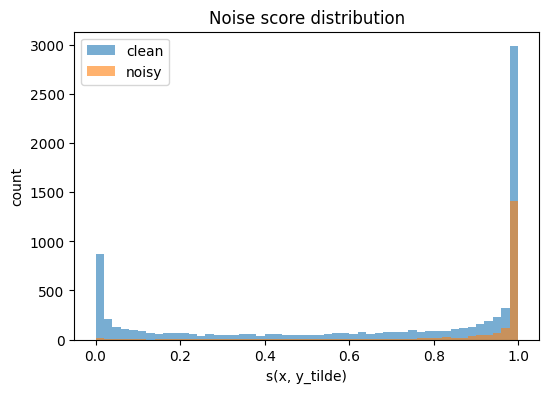

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(results["score"][results["is_noisy"] == 0], bins=50, alpha=0.6, label="clean")
plt.hist(results["score"][results["is_noisy"] == 1], bins=50, alpha=0.6, label="noisy")
plt.legend()
plt.title("Noise score distribution")
plt.xlabel("s(x, y_tilde)")
plt.ylabel("count")
plt.show()

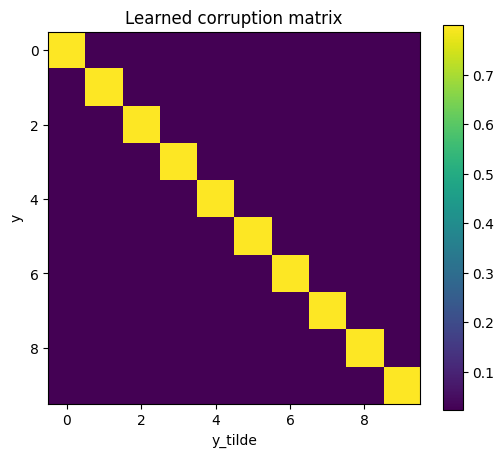

In [ ]:
with torch.no_grad():
    C_learned = model.corruption().cpu().numpy()

plt.figure(figsize=(6,5))
plt.imshow(C_learned, cmap="viridis")
plt.colorbar()
plt.title("Learned corruption matrix")
plt.xlabel("y_tilde")
plt.ylabel("y")
plt.show()

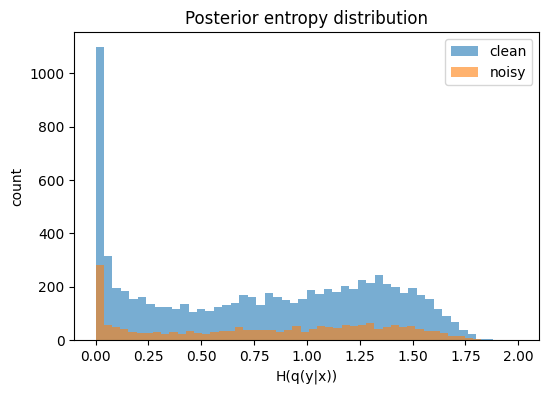

In [ ]:
posterior = results["posterior"]
entropy = -(posterior * np.log(posterior + 1e-8)).sum(axis=1)

clean_entropy = entropy[results["is_noisy"] == 0]
noisy_entropy = entropy[results["is_noisy"] == 1]

plt.figure(figsize=(6,4))
plt.hist(clean_entropy, bins=50, alpha=0.6, label="clean")
plt.hist(noisy_entropy, bins=50, alpha=0.6, label="noisy")
plt.legend()
plt.title("Posterior entropy distribution")
plt.xlabel("H(q(y|x))")
plt.ylabel("count")
plt.show()

In [ ]:
@torch.no_grad()
def collect_noise_scores(model, loader, device):
    model.eval()

    all_scores = []
    all_is_noisy = []
    all_y_true = []
    all_y_tilde = []
    all_posteriors = []
    all_indices = []

    for batch in loader:
        x = batch["x"].to(device)
        y_tilde = batch["y_noisy"].to(device)

        qy_logits = model.qy(x)
        qy_probs = torch.softmax(qy_logits, dim=1)

        prob_clean = qy_probs.gather(1, y_tilde.unsqueeze(1)).squeeze(1)
        score = 1.0 - prob_clean

        all_scores.append(score.cpu())
        all_posteriors.append(qy_probs.cpu())
        all_is_noisy.append(batch["is_noisy"])
        all_y_true.append(batch["y_true"])
        all_y_tilde.append(batch["y_noisy"])
        all_indices.append(batch["index"])

    return {
        "score": torch.cat(all_scores).numpy(),
        "posterior": torch.cat(all_posteriors).numpy(),
        "is_noisy": torch.cat(all_is_noisy).numpy(),
        "y_true": torch.cat(all_y_true).numpy(),
        "y_tilde": torch.cat(all_y_tilde).numpy(),
        "index": torch.cat(all_indices).numpy(),
    }

In [ ]:
train_ds = NoisyCIFAR10(train_base, C_true, seed=42)
test_ds  = NoisyCIFAR10(test_base, C_true, seed=123)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
results = collect_noise_scores(model, test_loader, device)

In [ ]:
def show_top_suspicious(dataset, results, class_names, top_k=10):
    idx_sorted = np.argsort(-results["score"])[:top_k]

    plt.figure(figsize=(15, 6))
    for i, ridx in enumerate(idx_sorted):
        ds_idx = int(results["index"][ridx])
        sample = dataset[ds_idx]

        x = sample["x"].permute(1, 2, 0).numpy()
        y_true = int(results["y_true"][ridx])
        y_tilde = int(results["y_tilde"][ridx])
        is_noisy = int(results["is_noisy"][ridx])
        score = float(results["score"][ridx])

        posterior = results["posterior"][ridx]
        top3 = np.argsort(-posterior)[:3]
        top3_text = ", ".join([f"{class_names[c]}:{posterior[c]:.2f}" for c in top3])

        plt.subplot(2, 5, i + 1)
        plt.imshow(x)
        plt.axis("off")
        plt.title(
            f"score={score:.2f}\n"
            f"true={class_names[y_true]}\n"
            f"noisy={class_names[y_tilde]}\n"
            f"is_noisy={is_noisy}\n"
            f"{top3_text}",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

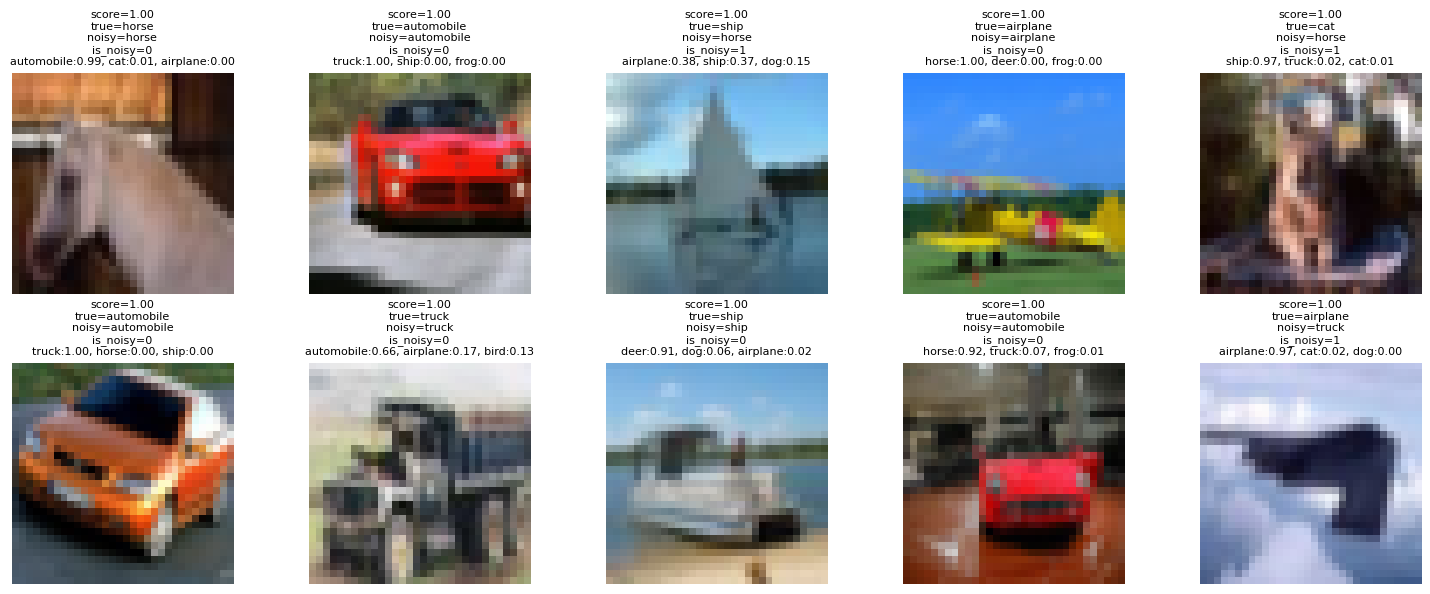

In [ ]:
show_top_suspicious(test_ds, results, class_names, top_k=10)

In [ ]:
def show_high_score_clean(dataset, results, class_names, top_k=10):
    mask = (results["is_noisy"] == 0)
    candidate_idx = np.where(mask)[0]
    sorted_idx = candidate_idx[np.argsort(-results["score"][candidate_idx])[:top_k]]

    plt.figure(figsize=(15, 6))
    for i, ridx in enumerate(sorted_idx):
        ds_idx = int(results["index"][ridx])
        sample = dataset[ds_idx]

        x = sample["x"].permute(1, 2, 0).numpy()
        y_true = int(results["y_true"][ridx])
        y_tilde = int(results["y_tilde"][ridx])
        score = float(results["score"][ridx])

        posterior = results["posterior"][ridx]
        top3 = np.argsort(-posterior)[:3]
        top3_text = ", ".join([f"{class_names[c]}:{posterior[c]:.2f}" for c in top3])

        plt.subplot(2, 5, i + 1)
        plt.imshow(x)
        plt.axis("off")
        plt.title(
            f"score={score:.2f}\n"
            f"true={class_names[y_true]}\n"
            f"noisy={class_names[y_tilde]}\n"
            f"{top3_text}",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

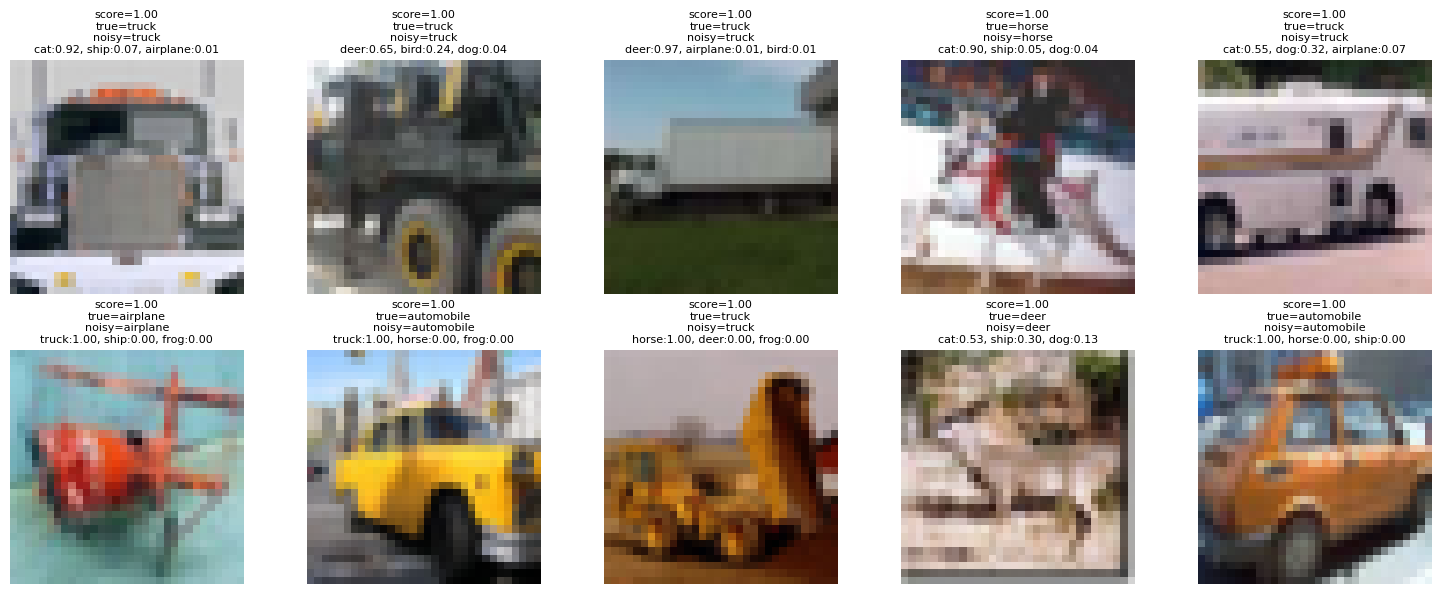

In [ ]:
show_high_score_clean(test_ds, results, class_names, top_k=10)

In [ ]:
def show_low_score_noisy(dataset, results, class_names, top_k=10):
    mask = (results["is_noisy"] == 1)
    candidate_idx = np.where(mask)[0]
    sorted_idx = candidate_idx[np.argsort(results["score"][candidate_idx])[:top_k]]

    plt.figure(figsize=(15, 6))
    for i, ridx in enumerate(sorted_idx):
        ds_idx = int(results["index"][ridx])
        sample = dataset[ds_idx]

        x = sample["x"].permute(1, 2, 0).numpy()
        y_true = int(results["y_true"][ridx])
        y_tilde = int(results["y_tilde"][ridx])
        score = float(results["score"][ridx])

        posterior = results["posterior"][ridx]
        top3 = np.argsort(-posterior)[:3]
        top3_text = ", ".join([f"{class_names[c]}:{posterior[c]:.2f}" for c in top3])

        plt.subplot(2, 5, i + 1)
        plt.imshow(x)
        plt.axis("off")
        plt.title(
            f"score={score:.2f}\n"
            f"true={class_names[y_true]}\n"
            f"noisy={class_names[y_tilde]}\n"
            f"{top3_text}",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

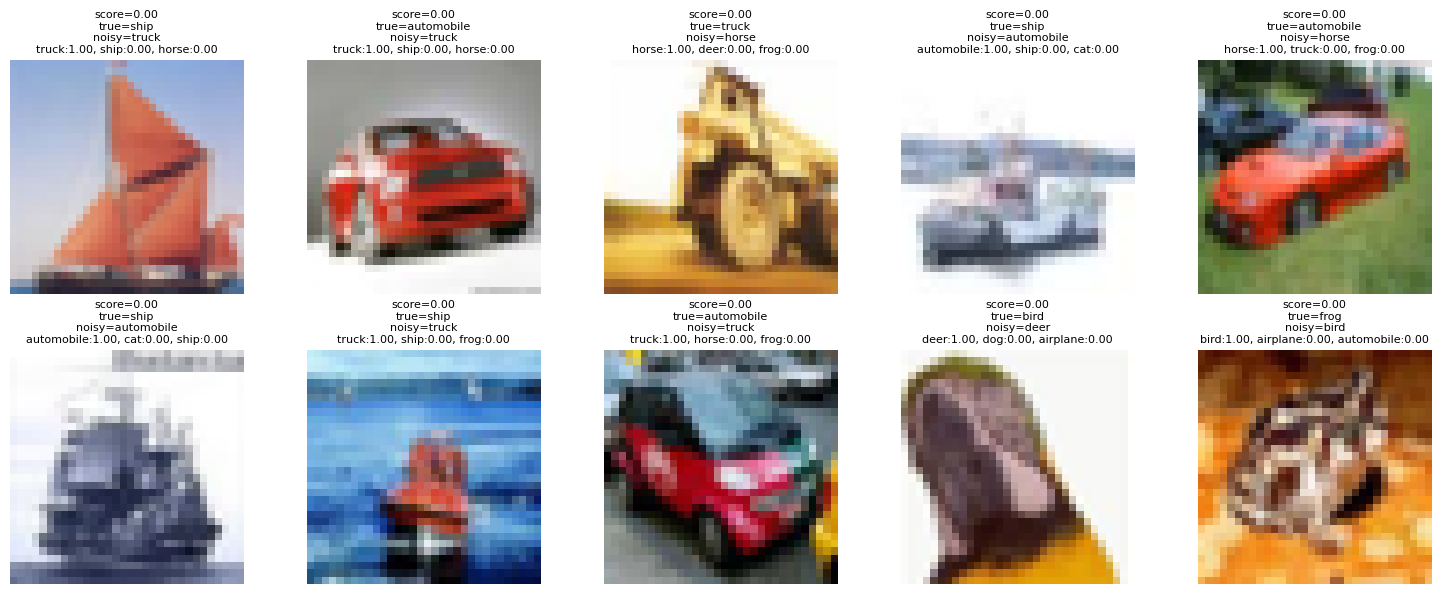

In [ ]:
show_low_score_noisy(test_ds, results, class_names, top_k=10)

In [ ]:
scores = results["score"]
labels = results["is_noisy"]

threshold = np.quantile(scores, 0.8)  # top 20% as predicted noisy
pred_noisy = (scores >= threshold).astype(int)

tp = np.sum((pred_noisy == 1) & (labels == 1))
fp = np.sum((pred_noisy == 1) & (labels == 0))
tn = np.sum((pred_noisy == 0) & (labels == 0))
fn = np.sum((pred_noisy == 0) & (labels == 1))

print("threshold:", threshold)
print("TP:", tp, "FP:", fp, "TN:", tn, "FN:", fn)
print("precision:", tp / (tp + fp + 1e-8))
print("recall:", tp / (tp + fn + 1e-8))

threshold: 0.9999751
TP: 716 FP: 1284 TN: 6695 FN: 1305
precision: 0.35799999999821003
recall: 0.3542800593747933


In [ ]:
clean_mask = (results["is_noisy"] == 0)
high_score_clean_mask = clean_mask & (results["score"] >= threshold)

high_score_clean_true = results["y_true"][high_score_clean_mask]
counts = np.bincount(high_score_clean_true, minlength=len(class_names))

for i, c in enumerate(counts):
    print(class_names[i], int(c))

airplane 55
automobile 258
bird 85
cat 60
deer 83
dog 46
frog 32
horse 233
ship 69
truck 363


In [ ]:
noisy_mask = (results["is_noisy"] == 1)
low_score_noisy_mask = noisy_mask & (results["score"] < threshold)

low_score_noisy_true = results["y_true"][low_score_noisy_mask]
counts = np.bincount(low_score_noisy_true, minlength=len(class_names))

for i, c in enumerate(counts):
    print(class_names[i], int(c))

airplane 136
automobile 99
bird 140
cat 119
deer 138
dog 141
frog 141
horse 143
ship 122
truck 126


In [ ]:
posterior_argmax = np.argmax(results["posterior"], axis=1)

high_score_clean_pred = posterior_argmax[high_score_clean_mask]
counts = np.bincount(high_score_clean_pred, minlength=len(class_names))

print("Predicted classes for high-score clean samples:")
for i, c in enumerate(counts):
    print(class_names[i], int(c))

Predicted classes for high-score clean samples:
airplane 127
automobile 224
bird 59
cat 102
deer 104
dog 96
frog 57
horse 134
ship 154
truck 227


In [ ]:
eta = 0.2
C_true_asym = make_asymmetric_cifar10_C(eta)
print(C_true_asym)

[[1.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  1.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.2 0.  0.8 0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.8 0.  0.2 0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.8 0.  0.  0.2 0.  0. ]
 [0.  0.  0.  0.2 0.  0.8 0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  1.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  1.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  1.  0. ]
 [0.  0.2 0.  0.  0.  0.  0.  0.  0.  0.8]]


In [ ]:
train_ds_asym = NoisyCIFAR10(train_base, C_true_asym, seed=42)
test_ds_asym  = NoisyCIFAR10(test_base, C_true_asym, seed=123)

train_loader_asym = DataLoader(train_ds_asym, batch_size=128, shuffle=True, num_workers=2)
test_loader_asym  = DataLoader(test_ds_asym, batch_size=256, shuffle=False, num_workers=2)

In [ ]:
print("train asym noise rate:", np.mean(train_ds_asym.is_noisy))
print("test asym noise rate:", np.mean(test_ds_asym.is_noisy))

train asym noise rate: 0.0988
test asym noise rate: 0.1007


In [ ]:
model_asym = DeepGenerativeNoiseModel(num_classes=10, z_dim=64, init_C=C_true_asym).to(device)
model_asym.corruption.logits.requires_grad = False

optimizer_asym = torch.optim.Adam(
    [p for p in model_asym.parameters() if p.requires_grad], lr=1e-3
)

In [ ]:
num_epochs = 20
for epoch in range(num_epochs):
    train_loss, train_stats = train_one_epoch(model_asym, train_loader_asym, optimizer_asym, device)
    test_loss, test_stats = eval_one_epoch(model_asym, test_loader_asym, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print("  train loss:", train_loss, train_stats)
    print("  test  loss:", test_loss, test_stats)

Epoch 1/20
  train loss: 1949.3277377734375 {'elbo': -1949.3277377734375, 'recon': -1930.2670350390624, 'kl_z': 30.075056477684974, 'log_p_ytilde_given_y': -8.717784982757568, 'entropy_qy': 0.9821598299980163}
  test  loss: 1891.124422265625 {'elbo': -1891.124422265625, 'recon': -1869.954499609375, 'kl_z': 40.09911474609375, 'log_p_ytilde_given_y': -7.519717041015625, 'entropy_qy': 0.6821291403770446}
Epoch 2/20
  train loss: 1865.5866516015626 {'elbo': -1865.5866516015626, 'recon': -1843.9865271484375, 'kl_z': 41.13878522705078, 'log_p_ytilde_given_y': -7.439979301910401, 'entropy_qy': 0.4840838179683685}
  test  loss: 1849.5163646484375 {'elbo': -1849.5163646484375, 'recon': -1827.4902962890626, 'kl_z': 43.736130700683596, 'log_p_ytilde_given_y': -7.0081154685974125, 'entropy_qy': 0.4054798082590103}
Epoch 3/20
  train loss: 1839.518237265625 {'elbo': -1839.518237265625, 'recon': -1817.8985959375, 'kl_z': 43.89085176025391, 'log_p_ytilde_given_y': -6.64081213684082, 'entropy_qy': 0.4

In [ ]:
results_asym = collect_noise_scores(model_asym, test_loader_asym, device)

roc_asym = roc_auc_score(results_asym["is_noisy"], results_asym["score"])
pr_asym = average_precision_score(results_asym["is_noisy"], results_asym["score"])

print("Asymmetric ROC-AUC:", roc_asym)
print("Asymmetric PR-AUC:", pr_asym)



Asymmetric ROC-AUC: 0.7180810717725835
Asymmetric PR-AUC: 0.17981376424621467


0.19425306 0.24288207


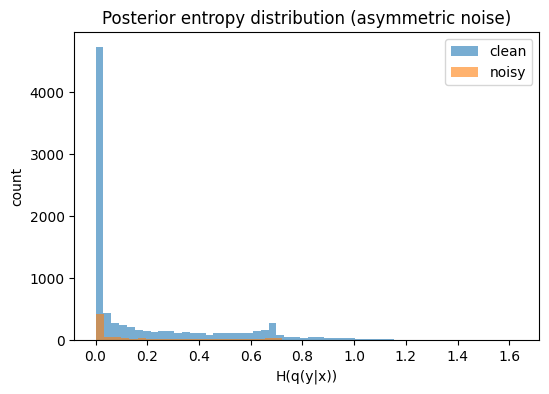

In [ ]:
posterior_asym = results_asym["posterior"]
entropy_asym = -(posterior_asym * np.log(posterior_asym + 1e-8)).sum(axis=1)

clean_entropy_asym = entropy_asym[results_asym["is_noisy"] == 0]
noisy_entropy_asym = entropy_asym[results_asym["is_noisy"] == 1]

print(clean_entropy_asym.mean(), noisy_entropy_asym.mean())

plt.figure(figsize=(6,4))
plt.hist(clean_entropy_asym, bins=50, alpha=0.6, label="clean")
plt.hist(noisy_entropy_asym, bins=50, alpha=0.6, label="noisy")
plt.legend()
plt.title("Posterior entropy distribution (asymmetric noise)")
plt.xlabel("H(q(y|x))")
plt.ylabel("count")
plt.show()

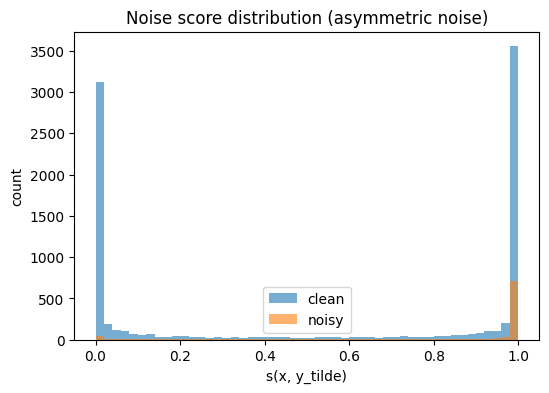

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(results_asym["score"][results_asym["is_noisy"] == 0], bins=50, alpha=0.6, label="clean")
plt.hist(results_asym["score"][results_asym["is_noisy"] == 1], bins=50, alpha=0.6, label="noisy")
plt.legend()
plt.title("Noise score distribution (asymmetric noise)")
plt.xlabel("s(x, y_tilde)")
plt.ylabel("count")
plt.show()

In [ ]:
results_asym = collect_noise_scores(model_asym, test_loader_asym, device)

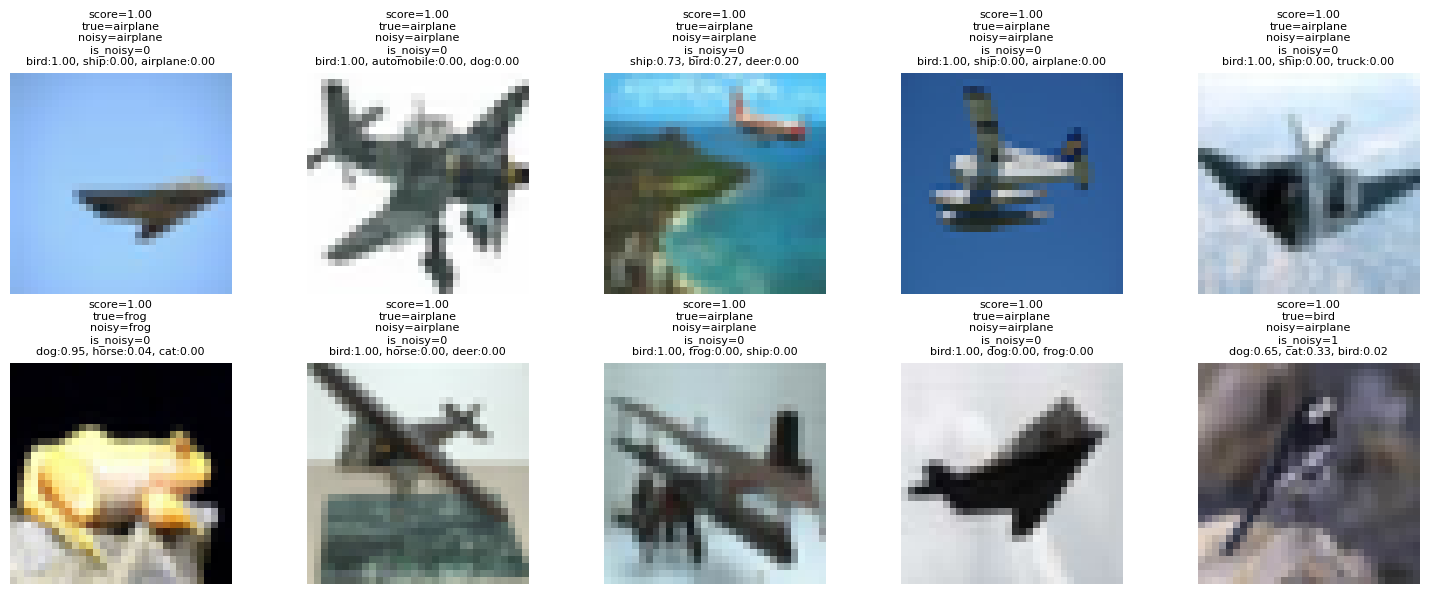

In [ ]:
show_top_suspicious(
    test_ds_asym,
    results_asym,
    class_names,
    top_k=10
)

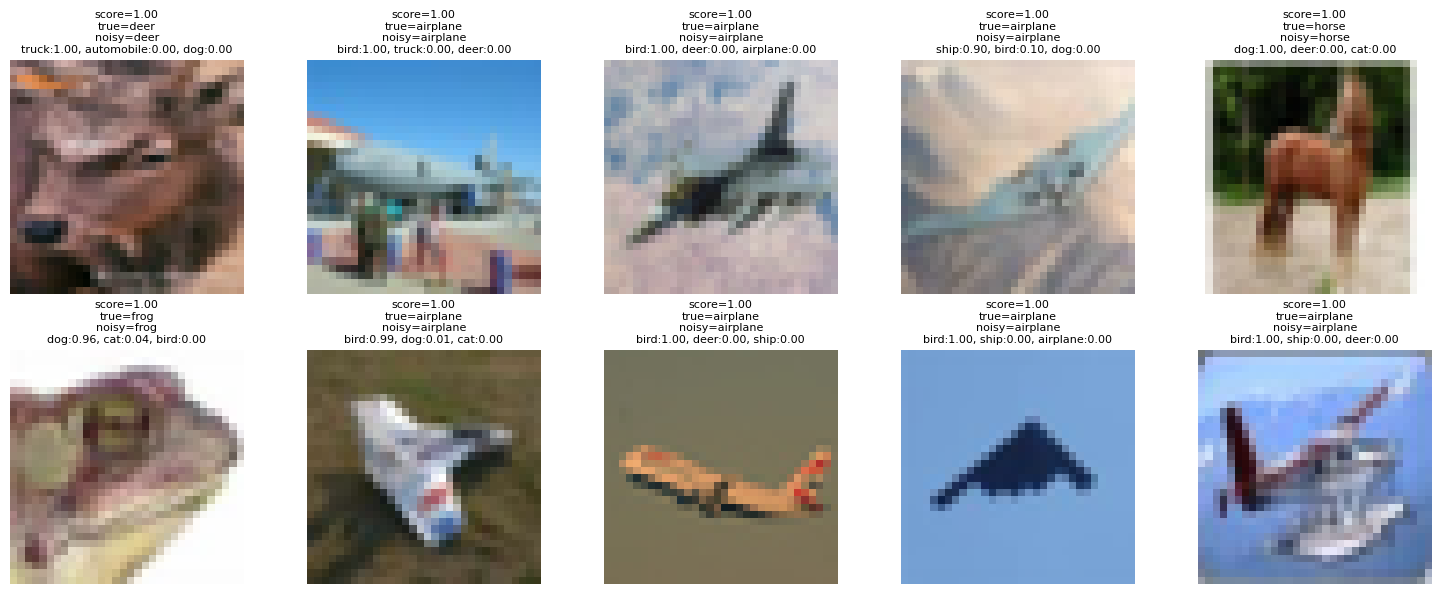

In [ ]:
show_high_score_clean(
    test_ds_asym,
    results_asym,
    class_names,
    top_k=10
)

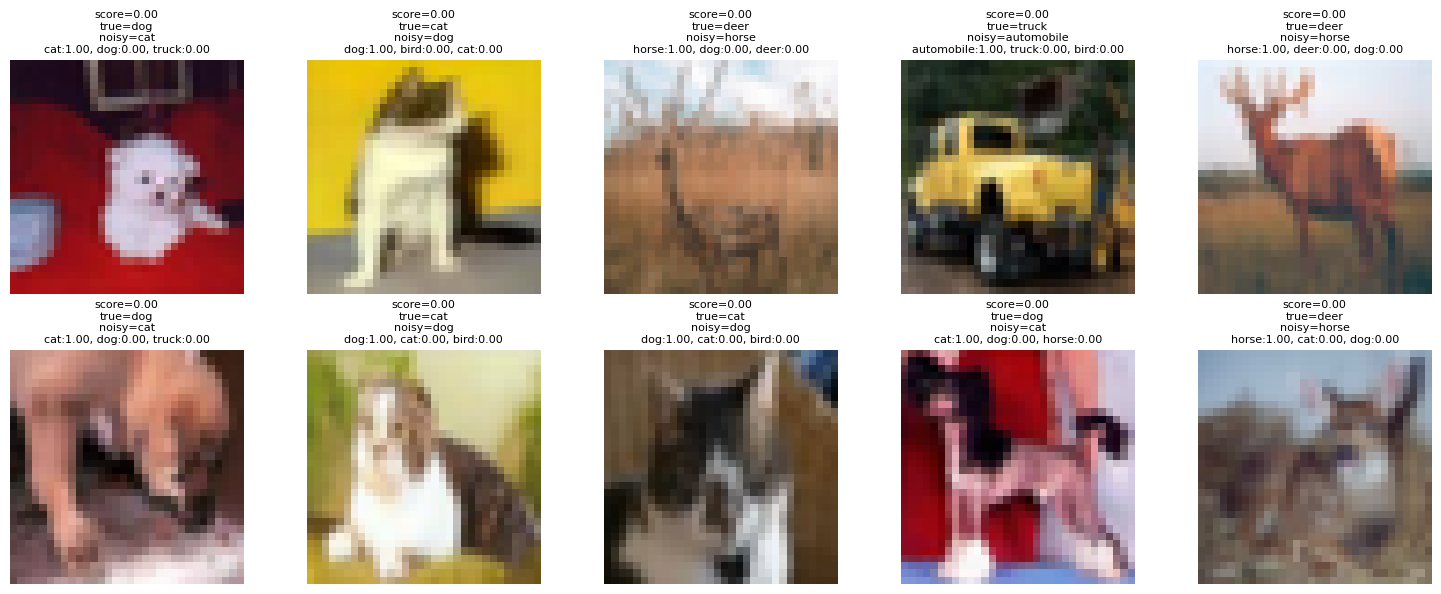

In [ ]:
show_low_score_noisy(
    test_ds_asym,
    results_asym,
    class_names,
    top_k=10
)

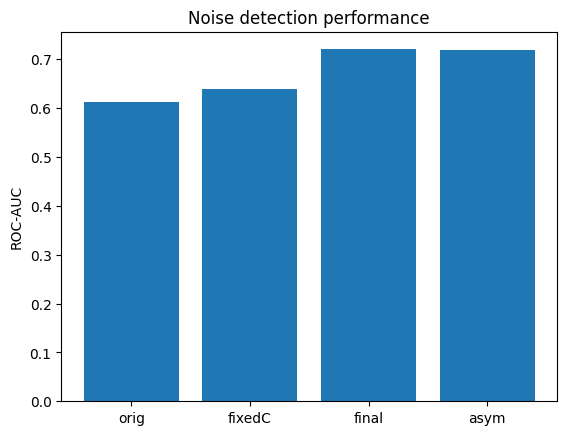

In [ ]:
labels = ["orig", "fixedC", "final", "asym"]
roc_scores = [0.612, 0.638, 0.720, 0.718]

plt.bar(labels, roc_scores)
plt.ylabel("ROC-AUC")
plt.title("Noise detection performance")
plt.show()